# 2022~2026년 확장 학습: 뉴스 포함 단일 모델과 방향·가격 앙상블

## 요약

DLinear·NLinear·XGBoost·LightGBM·PatchTST·TimesNet을 5·20·60거래일에서 다시 학습했다. **모든 후보는 뉴스 feature를 포함한 조건부 예측**이며 Naive/Persistence는 후보·앙상블 구성원에 없다. 최종 학습 표본은999/984/944건, 선택용 Validation은493/463/383건, 2026년 평가는179/164/124건이다.

| 지평 | Validation 균형정확도1위 | Validation 가격 RMSE1위 | 평균의 Validation 균형정확도 | 평균의2026 균형정확도 | 평균의2026 가격 RMSE |
|---|---|---|---:|---:|---:|
| 5일 | LightGBM300 | DLinear10 | 47.69% | 58.87% | 18.1677 |
| 20일 | LightGBM100 | XGBoost100 | 52.46% | 54.67% | 43.1259 |
| 60일 | DLinear30 | DLinear30 | 65.90% | 52.24% | 87.3405 |

모델명 뒤 숫자는 신경망 epoch 또는 트리 수다. 가격 RMSE 단위는 **센트/파운드**다. 60일은 같은 모델·설정이 두 기준을 모두 차지해 **단일 예측과 동일**하다.

- **5일:** 2026년 평균은 LightGBM 대비 균형정확도+6.40pp·RMSE3.53% 개선이지만, Validation 균형정확도는53.10%→47.69%로 악화했다. DLinear 대비2026 RMSE는0.35% 악화한다. 기간 전체에서 일관되게 우수한 앙상블은 아니다.
- **20일:** Validation 평균은 두 구성원보다 RMSE·균형정확도가 좋다. 그러나2026년에는 LightGBM 단일(균형55.85%, RMSE42.9016)이 평균(54.67%,43.1259)보다 좋다. 차이의 블록 구간은0을 포함한다.
- **60일:** DLinear30의 Validation 방향 적중률75.46%·균형65.90%가2026년50.81%·52.24%로 하락한다. 표본 확대만으로 기간별 성능 차이가 해결됐다고 볼 수 없다.
- 평가된 단일 설정 가운데2026년 사후 균형정확도 최고는5일 TimesNet10(58.30%),20일 TimesNet10(59.84%),60일 TimesNet30(54.69%)이다. **이 결과로 Validation 선택을 교체하지 않는다.** 모든 단일 설정은4절, 고정 구성원 대조는5절에 있다.

## 방법과 가정

- 기존 03_6/03_7의 부진을 표본 부족만의 결과로 단정하지 않는다. 이번에는 회귀 학습 origin을 2022년부터 늘리며, 2022~2026년 자료를 학습·선택·평가에 시간순으로 사용한다. 2026년 전체를 학습한 모델을 같은 기간에 평가하지 않는다.
- **선택용 확장 검증:** 2022~2023 학습→2024 Validation, 2022~2024 학습→2025 Validation. 해당 학습/검증 종료일까지 정답이 성숙한 사례만 쓴다. 두 해의 시점별 미학습 예측을 합쳐 모델과 설정을 선택한다.
- **고정 후 평가:** 2022~2025년으로 재학습→2026년 9월25일까지 성숙한 정답. 2024~2026년은 이전 연구에서 이미 본 자료이므로 새 미사용 Test가 아니라 재설계한 소급 평가다.
- 설정은 신경망10/30 epoch, 트리100/300 trees다. 각 모델의 균형정확도 최적 설정과 RMSE 최적 설정을 각각 보존한다. 전체 후보 중 균형정확도1위와 가격 RMSE1위를 골라 **가격을 50:50 평균**한다. 같은 모델·설정이 두 기준에서 모두1위면 중복 평균하지 않고 단일 예측으로 둔다. 같은 모델 종류의 서로 다른 설정이 선택되면 그 사실을 표시한다.
- 주 판단은 균형정확도·방향 적중률이며 상승 precision과 신호 건수를 함께 본다. 상승 누락률은 허용 가능한 기회 손실의 설명 지표, RMSE는 가격 오차의 보조 지표다. 회귀 학습 손실은 기존 MSE를 유지하며 직접 방향 분류를 새로 학습하는 실험은 아니다.
- 입력은 기존 가격4·거시3·기후/달력20개와 뉴스1개, 60거래일 창이다. 트리에도 같은 창을 펼쳐 제공한다. PatchTST/TimesNet은 기존 scalar 회귀 구현이다. 전처리·정답 표준화는 각 fold 학습 자료로만 맞춘다.
- 뉴스는 기존 `s_i = argmax 방향 × relevance × confidence`, 일별 `tanh(sum(s_i))`를 사용한다. **없는 날·점수0인 날은 같은 설정의27개 기본 모델 예측으로 복귀**한다. 기본 모델은 결측 처리용 구성요소이며 뉴스 없는 별도 비교 후보는 아니다. 모든 날짜를 평가에 남기며 이전 점수를 복사하지 않는다.
- 기사는 2026년 소급 분류이고 UTC23:00 연구 기준시각은 거래소 마감이 아니다. 실제 시점의 LLM 예측 가능성이나 그 종가에서의 주문 가능성을 입증하지 않는다. 2022년 이전 관측은60일 lookback·기후 기준값 등 과거 문맥으로만 사용하며 회귀 학습 origin은2022년 이후다. 한 seed와 제한된 설정 탐색 결과다.


In [1]:
import os,sys,json,hashlib,tempfile,platform,time
from pathlib import Path
for key in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","VECLIB_MAXIMUM_THREADS"):
    os.environ[key]="1"
os.environ.setdefault("MPLCONFIGDIR",str(Path(tempfile.gettempdir())/"coffee-matplotlib"))
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Markdown,display
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/"coffee_service").is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from data_code.fixed_ensemble_news import load_market,fixed_features,scores,average_prices,align_models,paired_interval,SEED
from data_code.news_expanding_benchmark import prepare_fold,fit_candidates
from coffee_service.transform import coffee_sessions
FONT={"Darwin":"AppleGothic","Windows":"Malgun Gothic"}.get(platform.system(),"NanumGothic")
assert FONT in {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family":FONT,"axes.unicode_minus":False,"figure.dpi":110,
    "axes.spines.top":False,"axes.spines.right":False})
def show(frame):display(Markdown(frame.to_markdown(index=False,floatfmt=".3f")))
SOURCE=ROOT/"data/processed/fixed_ensemble_news/sources_20260928"
NEWS_SOURCE=ROOT/"data/processed/news_feature_ensemble/ed374e9c9c0a19c6"
MODELS=("DLinear","NLinear","XGBoost","LightGBM","PatchTST","TimesNet")
HORIZONS=(5,20,60)
SETTINGS={m:([100,300] if m in ("XGBoost","LightGBM") else [10,30]) for m in MODELS}
VALIDATION_FOLDS=[("2023-12-31","2024-12-31"),("2024-12-31","2025-12-31")]
FINAL_CUTOFF="2025-12-31"
EVALUATION_END="2026-09-25"
inputs=[*sorted(SOURCE.glob("*.parquet")),NEWS_SOURCE/"daily_news.parquet",NEWS_SOURCE/"frozen_protocol.json",
    *[ROOT/f for f in ("data_code/news_expanding_benchmark.py","data_code/fixed_ensemble_news.py",
    "data_code/single_model_networks.py","coffee_service/modeling.py","coffee_service/transform.py",
    "coffee_service/features.py","coffee_service/training.py")]]
hashes={str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs}
notebook=json.loads((ROOT/"data_code/03_8_expanding_news_benchmark.ipynb").read_text())
code_text="\n".join("".join(c["source"]) for c in notebook["cells"] if c["cell_type"]=="code")
hashes["notebook_code"]=hashlib.sha256(code_text.encode()).hexdigest()
versions={name:version(name) for name in ("numpy","pandas","scikit-learn","torch","xgboost","lightgbm")}
versions["python"]=platform.python_version()
RUN=hashlib.sha256(json.dumps([hashes,versions],sort_keys=True).encode()).hexdigest()[:16]
OUTPUT=ROOT/"data/processed/news_feature_ensemble"/f"expanding_{RUN}"
OUTPUT.mkdir(parents=True,exist_ok=True)
print("출력:",OUTPUT.relative_to(ROOT))


출력: data/processed/news_feature_ensemble/expanding_7f2729fd5ce23b69


## 1. 입력과 표본 범위

기존 수치 snapshot과03_6의 일별 뉴스 집계를 재사용한다. 새 API 요청 없이 동일한 뉴스 정의로 표본 확대를 비교한다. 결측 뉴스는 NaN을 보존한다. 해를 넘겨 정답이 성숙하는 마지막 h개 origin은 해당 연도 Validation에서 제외되며, 모든 모델에 같은 기준이 적용된다.


In [2]:
sources,sessions,prices=load_market(SOURCE)
FEATURES,constant=fixed_features(sources,sessions)
assert len(FEATURES)==27
assert prices.close.dropna().index.max()==pd.Timestamp(EVALUATION_END)
daily=pd.read_parquet(NEWS_SOURCE/"daily_news.parquet").set_index("date")
assert not daily.index.has_duplicates and daily.index.is_monotonic_increasing
assert daily.index.equals(sessions[sessions>=pd.Timestamp("2022-01-01")])
news_feature=daily.news_sentiment
assert daily.news_present.eq(news_feature.notna()).all()
assert news_feature.dropna().between(-1,1).all()
news_audit=daily.assign(year=daily.index.year,active=news_feature.fillna(0).ne(0)).groupby("year").agg(
    거래일수=("news_present","size"),분석있는날=("news_present","sum"),방향뉴스있는날=("active","sum"))
show(news_audit.reset_index().rename(columns={"year":"연도"}))
print("피처:",FEATURES+["news_sentiment"])

def check_predictions(frame,prepared,name,settings):
    assert set(frame.setting)==set(settings) and frame.model.eq(name).all()
    reference=prepared["reference"].reset_index(drop=True)
    keys=["origin_date","target_date","actual_return","current_price","news_present","news_used"]
    for setting,part in frame.groupby("setting"):
        part=part.sort_values("origin_date").reset_index(drop=True)
        pd.testing.assert_frame_equal(part[keys],reference[keys],check_exact=True)
        assert part.train_cutoff.eq(reference.train_cutoff.iloc[0]).all()
        assert part.train_rows.eq(reference.train_rows.iloc[0]).all()
        assert part.feature_count.eq(28).all() and part.use_news.all()
        inactive=~part.news_used
        np.testing.assert_array_equal(part.loc[inactive,"predicted_return"],part.loc[inactive,"base_prediction"])
        np.testing.assert_array_equal(part.loc[~inactive,"predicted_return"],part.loc[~inactive,"news_prediction"])
        scores(part,part.predicted_return)

# 모델과 예측은 입력·코드 해시별 경로로 분리한다.
def run_candidates(prepared,name,settings,fold,horizon):
    folder=OUTPUT/"models"/f"{fold}_{horizon}"/name
    folder.mkdir(parents=True,exist_ok=True)
    path=folder/"predictions.parquet"
    if path.exists():
        frame=pd.read_parquet(path)
        assert set(settings).issubset(set(frame.setting))
        frame=frame.loc[frame.setting.isin(settings)].copy()
        status="저장 예측 재사용"
    else:
        frame=fit_candidates(name,settings,prepared,folder)
        check_predictions(frame,prepared,name,settings)
        temporary=folder/"predictions.tmp.parquet"
        frame.to_parquet(temporary,index=False);temporary.replace(path)
        status="학습 완료"
    check_predictions(frame,prepared,name,settings)
    print(f"{fold} | {horizon}일 | {name} | {status}",flush=True)
    return frame.assign(fold=fold,horizon=horizon,candidate=frame.model+"@"+frame.setting.astype(str))

def metric_row(frame):
    predicted_up=frame.predicted_return.to_numpy()>0
    actual_up=frame.actual_return.to_numpy()>0
    signals=int(predicted_up.sum());hits=int((predicted_up&actual_up).sum())
    return {**scores(frame,frame.predicted_return),"상승 precision (%)":100*hits/signals if signals else np.nan,
        "상승 예측 건수":signals,"상승 적중 건수":hits,"실제 상승 비율 (%)":100*actual_up.mean()}


|   연도 |   거래일수 |   분석있는날 |   방향뉴스있는날 |
|-------:|-----------:|-------------:|-----------------:|
|   2022 |        251 |          166 |               35 |
|   2023 |        250 |          187 |               39 |
|   2024 |        252 |          218 |               64 |
|   2025 |        251 |          241 |              113 |
|   2026 |        184 |          181 |              129 |

피처: ['return_1', 'return_5', 'return_20', 'volatility_20', 'brl_change_20', 'rate_change_20', 'oil_change_20', 'br_sul_minas_rain_anomaly', 'br_sul_minas_temp_anomaly', 'br_sul_minas_drought', 'br_cerrado_rain_anomaly', 'br_cerrado_temp_anomaly', 'br_cerrado_drought', 'br_alta_mogiana_rain_anomaly', 'br_alta_mogiana_temp_anomaly', 'br_alta_mogiana_drought', 'co_huila_rain_anomaly', 'co_huila_temp_anomaly', 'co_huila_drought', 'co_caldas_rain_anomaly', 'co_caldas_temp_anomaly', 'co_caldas_drought', 'co_antioquia_rain_anomaly', 'co_antioquia_temp_anomaly', 'co_antioquia_drought', 'month_sin', 'month_cos', 'news_sentiment']


## 2. 2024·2025년 확장 Validation

한 fold의 모든 설정은 같은 전처리·훈련/평가 날짜를 사용한다. 신경망은30 epoch까지 한 번 학습하며10/30 지점을 비교한다. 모든 후보는 동일한 조건부 뉴스 규칙을 사용한다. 아래 파일 재사용은 입력·코드·버전 해시가 같은 경우에만 가능하다.


In [3]:
validation_parts=[];fold_audit=[]
for cutoff,end in VALIDATION_FOLDS:
    fold=f"validation_{pd.Timestamp(end).year}"
    for h in HORIZONS:
        prepared=prepare_fold(sources,sessions,FEATURES,news_feature,h,cutoff,end)
        reference=prepared["reference"]
        fold_audit.append({"구분":fold,"지평":h,"학습 정답 마감":cutoff,"평가 정답 마감":end,
            "학습 표본":int(reference.train_rows.iloc[0]),"평가 표본":len(reference),
            "평가 시작":str(reference.origin_date.min().date()),"평가 끝":str(reference.origin_date.max().date()),
            "뉴스 적용일":int(reference.news_used.sum())})
        for name in MODELS:
            validation_parts.append(run_candidates(prepared,name,SETTINGS[name],fold,h))
validation_predictions=pd.concat(validation_parts,ignore_index=True)
assert validation_predictions.target_date.le(FINAL_CUTOFF).all()
assert validation_predictions.origin_date.dt.year.isin([2024,2025]).all()
assert not validation_predictions.duplicated(["horizon","candidate","origin_date"]).any()
validation_rows=[]
for (h,candidate),part in validation_predictions.groupby(["horizon","candidate"]):
    validation_rows.append({"지평":h,"후보":candidate,"모델":part.model.iloc[0],"설정":int(part.setting.iloc[0]),**metric_row(part)})
validation=pd.DataFrame(validation_rows)
show(pd.DataFrame(fold_audit))


validation_2024 | 5일 | DLinear | 저장 예측 재사용


validation_2024 | 5일 | NLinear | 저장 예측 재사용


validation_2024 | 5일 | XGBoost | 저장 예측 재사용


validation_2024 | 5일 | LightGBM | 저장 예측 재사용


validation_2024 | 5일 | PatchTST | 저장 예측 재사용


...

validation_2025 | 60일 | XGBoost | 저장 예측 재사용


validation_2025 | 60일 | LightGBM | 저장 예측 재사용


validation_2025 | 60일 | PatchTST | 저장 예측 재사용

validation_2025 | 60일 | TimesNet | 저장 예측 재사용

| 구분            |   지평 | 학습 정답 마감   | 평가 정답 마감   |   학습 표본 |   평가 표본 | 평가 시작   | 평가 끝    |   뉴스 적용일 |
|:----------------|-------:|:-----------------|:-----------------|------------:|------------:|:------------|:-----------|--------------:|
| validation_2024 |      5 | 2023-12-31       | 2024-12-31       |         496 |         247 | 2024-01-02  | 2024-12-23 |            63 |
| validation_2024 |     20 | 2023-12-31       | 2024-12-31       |         481 |         232 | 2024-01-02  | 2024-12-02 |            58 |
| validation_2024 |     60 | 2023-12-31       | 2024-12-31       |         441 |         192 | 2024-01-02  | 2024-10-04 |            47 |
| validation_2025 |      5 | 2024-12-31       | 2025-12-31       |         748 |         246 | 2025-01-02  | 2025-12-23 |           113 |
| validation_2025 |     20 | 2024-12-31       | 2025-12-31       |         733 |         231 | 2025-01-02  | 2025-12-02 |           102 |
| validation_2025 |     60 | 2024-12-31       | 2025-12-31       |         693 |         191 | 2025-01-02  | 2025-10-06 |            77 |

## 3. 단일 모델 비교와 두 구성원 고정

균형정확도 기준은 높은 균형정확도→낮은 RMSE→모델명·설정 순으로, RMSE 기준은 낮은 RMSE→높은 균형정확도→모델명·설정 순으로 정렬한다. 상승 누락률에는 벌점을 주지 않는다. 각 모델의 두 기준 최적 설정과 전체 최고 두 후보를 모두 기록한다. 후보 선택용 수치는 두 Validation 연도의 예측을 합쳐 직접 계산하며 연도별 비율을 단순평균하지 않는다.


In [4]:
RANKING={"균형정확도":[["균형 정확도 (%)","가격 RMSE","모델","설정"],[False,True,True,True]],
         "RMSE":[["가격 RMSE","균형 정확도 (%)","모델","설정"],[True,False,True,True]]}
def best(table,criterion):
    columns,ascending=RANKING[criterion]
    return table.sort_values(columns,ascending=ascending,kind="stable").iloc[0]
per_model=[];leaders=[]
for h,table in validation.groupby("지평"):
    assert table["균형 정확도 (%)"].notna().all()
    for criterion in RANKING:
        leaders.append({"선택 기준":criterion,**best(table,criterion).to_dict()})
        for name,group in table.groupby("모델"):
            per_model.append({"선택 기준":criterion,**best(group,criterion).to_dict()})
per_model=pd.DataFrame(per_model);leaders=pd.DataFrame(leaders)
for h in HORIZONS:
    display(Markdown(f"### {h}일 · 모델별 두 기준 최적 설정"))
    show(per_model.loc[per_model["지평"].eq(h),["선택 기준","모델","설정","표본","가격 RMSE","방향 적중률 (%)","균형 정확도 (%)","상승 precision (%)"]])
show(leaders[["지평","선택 기준","후보","가격 RMSE","방향 적중률 (%)","균형 정확도 (%)"]])
ensemble_members={h:list(dict.fromkeys(leaders.loc[leaders["지평"].eq(h),"후보"])) for h in HORIZONS}
protocol={"method":"expanding_conditional_news_six_models","hashes":hashes,"versions":versions,
    "train_origin_start":"2022-01-01","validation_folds":VALIDATION_FOLDS,"selection_cutoff":FINAL_CUTOFF,
    "evaluation_end":EVALUATION_END,"features":FEATURES+["news_sentiment"],"seed":SEED,
    "settings":SETTINGS,"ranking":RANKING,"missing_news":"fallback to same-setting base model when absent or zero",
    "per_model":per_model[["지평","선택 기준","모델","설정","후보"]].to_dict("records"),
    "leaders":leaders[["지평","선택 기준","모델","설정","후보"]].to_dict("records"),
    "ensemble_members":ensemble_members,"ensemble":"equal average of unique member prices"}
protocol_text=json.dumps(protocol,ensure_ascii=False,indent=2,allow_nan=False)
protocol_path=OUTPUT/"frozen_protocol.json"
if protocol_path.exists():assert protocol_path.read_text()==protocol_text,"고정 선택 충돌"
else:protocol_path.write_text(protocol_text)
print("2026년 평가 전에 선택 저장:",protocol_path.relative_to(ROOT))


### 5일 · 모델별 두 기준 최적 설정

| 선택 기준   | 모델     |   설정 |   표본 |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 precision (%) |
|:------------|:---------|-------:|-------:|------------:|------------------:|------------------:|---------------------:|
| 균형정확도  | DLinear  |     30 |    493 |      18.610 |            53.753 |            52.231 |               57.099 |
| 균형정확도  | LightGBM |    300 |    493 |      19.177 |            54.361 |            53.104 |               57.643 |
| 균형정확도  | NLinear  |     30 |    493 |      20.563 |            42.799 |            44.374 |               47.541 |
| 균형정확도  | PatchTST |     10 |    493 |      18.877 |            47.870 |            45.719 |               52.450 |
| 균형정확도  | TimesNet |     30 |    493 |      27.478 |            49.899 |            50.092 |               55.466 |
| 균형정확도  | XGBoost  |    300 |    493 |      19.064 |            50.913 |            50.037 |               55.254 |
| RMSE        | DLinear  |     10 |    493 |      18.308 |            48.073 |            46.687 |               52.866 |
| RMSE        | LightGBM |    100 |    493 |      18.582 |            50.101 |            48.565 |               54.180 |
| RMSE        | NLinear  |     10 |    493 |      19.548 |            40.974 |            42.772 |               45.029 |
| RMSE        | PatchTST |     10 |    493 |      18.877 |            47.870 |            45.719 |               52.450 |
| RMSE        | TimesNet |     10 |    493 |      21.669 |            47.465 |            47.524 |               52.988 |
| RMSE        | XGBoost  |    100 |    493 |      18.535 |            50.304 |            49.395 |               54.730 |

### 20일 · 모델별 두 기준 최적 설정

| 선택 기준   | 모델     |   설정 |   표본 |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 precision (%) |
|:------------|:---------|-------:|-------:|------------:|------------------:|------------------:|---------------------:|
| 균형정확도  | DLinear  |     30 |    463 |      47.271 |            49.892 |            45.108 |               55.840 |
| 균형정확도  | LightGBM |    100 |    463 |      38.517 |            53.780 |            52.085 |               60.650 |
| 균형정확도  | NLinear  |     10 |    463 |      39.071 |            50.540 |            51.018 |               60.000 |
| 균형정확도  | PatchTST |     10 |    463 |      44.635 |            42.549 |            43.681 |               51.777 |
| 균형정확도  | TimesNet |     10 |    463 |      54.292 |            43.629 |            44.997 |               53.125 |
| 균형정확도  | XGBoost  |    300 |    463 |      38.599 |            50.108 |            49.612 |               58.607 |
| RMSE        | DLinear  |     10 |    463 |      39.546 |            46.868 |            43.504 |               54.313 |
| RMSE        | LightGBM |    100 |    463 |      38.517 |            53.780 |            52.085 |               60.650 |
| RMSE        | NLinear  |     10 |    463 |      39.071 |            50.540 |            51.018 |               60.000 |
| RMSE        | PatchTST |     10 |    463 |      44.635 |            42.549 |            43.681 |               51.777 |
| RMSE        | TimesNet |     10 |    463 |      54.292 |            43.629 |            44.997 |               53.125 |
| RMSE        | XGBoost  |    100 |    463 |      38.498 |            49.244 |            48.959 |               57.983 |

### 60일 · 모델별 두 기준 최적 설정

| 선택 기준   | 모델     |   설정 |   표본 |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 precision (%) |
|:------------|:---------|-------:|-------:|------------:|------------------:|------------------:|---------------------:|
| 균형정확도  | DLinear  |     30 |    383 |      43.981 |            75.457 |            65.897 |               83.333 |
| 균형정확도  | LightGBM |    100 |    383 |      62.931 |            29.243 |            41.224 |               61.176 |
| 균형정확도  | NLinear  |     30 |    383 |      67.637 |            50.392 |            42.406 |               71.186 |
| 균형정확도  | PatchTST |     30 |    383 |      78.668 |            28.721 |            44.896 |               63.934 |
| 균형정확도  | TimesNet |     10 |    383 |      74.857 |            37.598 |            40.532 |               66.887 |
| 균형정확도  | XGBoost  |    300 |    383 |      60.703 |            29.504 |            46.874 |               67.857 |
| RMSE        | DLinear  |     30 |    383 |      43.981 |            75.457 |            65.897 |               83.333 |
| RMSE        | LightGBM |    100 |    383 |      62.931 |            29.243 |            41.224 |               61.176 |
| RMSE        | NLinear  |     30 |    383 |      67.637 |            50.392 |            42.406 |               71.186 |
| RMSE        | PatchTST |     30 |    383 |      78.668 |            28.721 |            44.896 |               63.934 |
| RMSE        | TimesNet |     30 |    383 |      70.615 |            41.514 |            40.197 |               68.132 |
| RMSE        | XGBoost  |    300 |    383 |      60.703 |            29.504 |            46.874 |               67.857 |

|   지평 | 선택 기준   | 후보         |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |
|-------:|:------------|:-------------|------------:|------------------:|------------------:|
|      5 | 균형정확도  | LightGBM@300 |      19.177 |            54.361 |            53.104 |
|      5 | RMSE        | DLinear@10   |      18.308 |            48.073 |            46.687 |
|     20 | 균형정확도  | LightGBM@100 |      38.517 |            53.780 |            52.085 |
|     20 | RMSE        | XGBoost@100  |      38.498 |            49.244 |            48.959 |
|     60 | 균형정확도  | DLinear@30   |      43.981 |            75.457 |            65.897 |
|     60 | RMSE        | DLinear@30   |      43.981 |            75.457 |            65.897 |

2026년 평가 전에 선택 저장: data/processed/news_feature_ensemble/expanding_7f2729fd5ce23b69/frozen_protocol.json


## 4. 2022~2025년 재학습 후 2026년 평가

각 모델에서 Validation으로 고른 두 설정의 합집합만 재학습한다. 이후 가격·방향 결과를 보고 설정이나 앙상블 구성원을 바꾸지 않는다. 두 기준이 같은 설정을 골랐으면 한 번만 학습한다. 평가일은 지평별 정답 성숙 여부에 따라 다르며 같은 지평의 모든 모델은 같은 날짜다.


In [5]:
assert protocol_path.read_text()==protocol_text
evaluation_parts=[]
for h in HORIZONS:
    prepared=prepare_fold(sources,sessions,FEATURES,news_feature,h,FINAL_CUTOFF,EVALUATION_END)
    reference=prepared["reference"]
    fold_audit.append({"구분":"evaluation_2026","지평":h,"학습 정답 마감":FINAL_CUTOFF,"평가 정답 마감":EVALUATION_END,
        "학습 표본":int(reference.train_rows.iloc[0]),"평가 표본":len(reference),
        "평가 시작":str(reference.origin_date.min().date()),"평가 끝":str(reference.origin_date.max().date()),
        "뉴스 적용일":int(reference.news_used.sum())})
    for name in MODELS:
        settings=sorted(int(s) for s in per_model.loc[per_model["지평"].eq(h)&per_model["모델"].eq(name),"설정"].unique())
        evaluation_parts.append(run_candidates(prepared,name,settings,"evaluation_2026",h))
evaluation_predictions=pd.concat(evaluation_parts,ignore_index=True)
assert evaluation_predictions.train_cutoff.eq(pd.Timestamp(FINAL_CUTOFF)).all()
assert evaluation_predictions.origin_date.dt.year.eq(2026).all()
assert evaluation_predictions.target_date.le(EVALUATION_END).all()
evaluation_rows=[]
for (h,candidate),part in evaluation_predictions.groupby(["horizon","candidate"]):
    roles=per_model.loc[per_model["지평"].eq(h)&per_model["후보"].eq(candidate),"선택 기준"]
    evaluation_rows.append({"지평":h,"후보":candidate,"설정 선택 기준":" / ".join(roles),**metric_row(part)})
evaluation=pd.DataFrame(evaluation_rows)
for h in HORIZONS:
    display(Markdown(f"### {h}일 · 2026년 단일 모델"))
    show(evaluation.loc[evaluation["지평"].eq(h)])
show(pd.DataFrame(fold_audit).loc[lambda d:d["구분"].eq("evaluation_2026")])


evaluation_2026 | 5일 | DLinear | 저장 예측 재사용


evaluation_2026 | 5일 | NLinear | 저장 예측 재사용


evaluation_2026 | 5일 | XGBoost | 저장 예측 재사용


evaluation_2026 | 5일 | LightGBM | 저장 예측 재사용


evaluation_2026 | 5일 | PatchTST | 저장 예측 재사용


...

### 20일 · 2026년 단일 모델

|   지평 | 후보         | 설정 선택 기준    |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   상승 precision (%) |   상승 예측 건수 |   상승 적중 건수 |   실제 상승 비율 (%) |
|-------:|:-------------|:------------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|---------------------:|-----------------:|-----------------:|---------------------:|
|     20 | DLinear@10   | RMSE              |    164 |      46.697 |         0.150 |            49.390 |            49.717 |            23.457 |               49.206 |              126 |               62 |               49.390 |
|     20 | DLinear@30   | 균형정확도        |    164 |      56.090 |         0.177 |            51.220 |            51.569 |            19.753 |               50.388 |              129 |               65 |               49.390 |
|     20 | LightGBM@100 | 균형정확도 / RMSE |    164 |      42.902 |         0.137 |            55.488 |            55.846 |            14.815 |               53.077 |              130 |               69 |               49.390 |
|     20 | NLinear@10   | 균형정확도 / RMSE |    164 |      47.510 |         0.149 |            56.707 |            57.214 |             1.235 |               53.333 |              150 |               80 |               49.390 |
|     20 | PatchTST@10  | 균형정확도 / RMSE |    164 |      44.283 |         0.143 |            45.122 |            45.337 |            37.037 |               45.946 |              111 |               51 |               49.390 |
|     20 | TimesNet@10  | 균형정확도 / RMSE |    164 |      44.025 |         0.137 |            59.756 |            59.839 |            33.333 |               58.065 |               93 |               54 |               49.390 |
|     20 | XGBoost@100  | RMSE              |    164 |      43.416 |         0.139 |            50.610 |            51.026 |            14.815 |               50.000 |              138 |               69 |               49.390 |
|     20 | XGBoost@300  | 균형정확도        |    164 |      44.034 |         0.141 |            48.780 |            49.115 |            23.457 |               48.819 |              127 |               62 |               49.390 |

### 60일 · 2026년 단일 모델

|   지평 | 후보         | 설정 선택 기준    |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   상승 precision (%) |   상승 예측 건수 |   상승 적중 건수 |   실제 상승 비율 (%) |
|-------:|:-------------|:------------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|---------------------:|-----------------:|-----------------:|---------------------:|
|     60 | DLinear@30   | 균형정확도 / RMSE |    124 |      87.340 |         0.253 |            50.806 |            52.240 |             3.333 |               49.573 |              117 |               58 |               48.387 |
|     60 | LightGBM@100 | 균형정확도 / RMSE |    124 |      52.249 |         0.174 |            37.903 |            36.875 |            95.000 |               13.043 |               23 |                3 |               48.387 |
|     60 | NLinear@30   | 균형정확도 / RMSE |    124 |      68.227 |         0.240 |            16.935 |            16.667 |            91.667 |                9.434 |               53 |                5 |               48.387 |
|     60 | PatchTST@30  | 균형정확도 / RMSE |    124 |      57.527 |         0.192 |            43.548 |            43.594 |            55.000 |               42.188 |               64 |               27 |               48.387 |
|     60 | TimesNet@10  | 균형정확도        |    124 |      48.052 |         0.149 |            53.226 |            53.854 |            26.667 |               51.163 |               86 |               44 |               48.387 |
|     60 | TimesNet@30  | RMSE              |    124 |      51.740 |         0.161 |            54.032 |            54.688 |            25.000 |               51.724 |               87 |               45 |               48.387 |
|     60 | XGBoost@300  | 균형정확도 / RMSE |    124 |      50.465 |         0.168 |            37.097 |            36.406 |            85.000 |               25.000 |               36 |                9 |               48.387 |

| 구분            |   지평 | 학습 정답 마감   | 평가 정답 마감   |   학습 표본 |   평가 표본 | 평가 시작   | 평가 끝    |   뉴스 적용일 |
|:----------------|-------:|:-----------------|:-----------------|------------:|------------:|:------------|:-----------|--------------:|
| evaluation_2026 |      5 | 2025-12-31       | 2026-09-25       |         999 |         179 | 2026-01-02  | 2026-09-18 |           124 |
| evaluation_2026 |     20 | 2025-12-31       | 2026-09-25       |         984 |         164 | 2026-01-02  | 2026-08-27 |           111 |
| evaluation_2026 |     60 | 2025-12-31       | 2026-09-25       |         944 |         124 | 2026-01-02  | 2026-07-01 |            75 |

## 5. 균형정확도1위 + RMSE1위 가격 단순평균

선택한 두 구성원과 평균을 동일 날짜에서 직접 비교한다. 모든 단일 후보의 날짜·정답·현재 가격도 일치하는지 검사한다. 아래 Validation 앙상블은 구성원 선택에 사용한 기간의 탐색적 성적이며, 개선 여부의 주 확인은 고정 후2026 평가다. 같은 후보가 두 기준에서 선택되면 평균도 그 단일 예측과 정확히 같아야 한다.


In [6]:
all_forecasts=[];comparison_rows=[]
for split,raw in [("2024~2025 Validation",validation_predictions),("2026 평가",evaluation_predictions)]:
    for h in HORIZONS:
        part=raw.loc[raw.horizon.eq(h)].copy()
        part["model"]=part.candidate
        reference,predictions=align_models(part,tuple(sorted(part.candidate.unique())))
        for candidate in predictions:
            all_forecasts.append(reference.assign(split=split,horizon=h,candidate=candidate,
                predicted_return=predictions[candidate].to_numpy()).reset_index())
        members=ensemble_members[h]
        mean=predictions[members[0]].to_numpy() if len(members)==1 else average_prices(predictions[members])
        ensemble=reference.assign(split=split,horizon=h,candidate="방향+가격 앙상블",predicted_return=mean).reset_index()
        all_forecasts.append(ensemble)
        for criterion in RANKING:
            member=leaders.loc[leaders["지평"].eq(h)&leaders["선택 기준"].eq(criterion),"후보"].item()
            result=reference.assign(predicted_return=predictions[member].to_numpy())
            comparison_rows.append({"기간":split,"지평":h,"역할":criterion+" 1위","구성":member,**metric_row(result)})
        comparison_rows.append({"기간":split,"지평":h,"역할":"가격 단순평균","구성":" + ".join(members),**metric_row(ensemble)})
        actual_mean=np.mean(np.column_stack([reference.current_price*np.exp(predictions[m]) for m in members]),axis=1)
        np.testing.assert_allclose(reference.current_price*np.exp(mean),actual_mean,rtol=1e-12,atol=1e-12)
all_forecasts=pd.concat(all_forecasts,ignore_index=True)
comparison=pd.DataFrame(comparison_rows)
for split in comparison["기간"].unique():
    display(Markdown("### "+split))
    show(comparison.loc[comparison["기간"].eq(split)])
# 연도별 Validation을 나누어 방향 성능의 안정성을 확인한다.
yearly=[]
for (h,candidate,year),part in all_forecasts.assign(year=all_forecasts.origin_date.dt.year).groupby(["horizon","candidate","year"]):
    if candidate not in [*ensemble_members[h],"방향+가격 앙상블"]:continue
    yearly.append({"지평":h,"후보":candidate,"연도":year,**metric_row(part)})
yearly=pd.DataFrame(yearly)
show(yearly[["지평","후보","연도","표본","가격 RMSE","방향 적중률 (%)","균형 정확도 (%)"]])


### 2024~2025 Validation

| 기간                 |   지평 | 역할           | 구성                       |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   상승 precision (%) |   상승 예측 건수 |   상승 적중 건수 |   실제 상승 비율 (%) |
|:---------------------|-------:|:---------------|:---------------------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|---------------------:|-----------------:|-----------------:|---------------------:|
| 2024~2025 Validation |      5 | 균형정확도 1위 | LightGBM@300               |    493 |      19.177 |         0.059 |            54.361 |            53.104 |            33.700 |               57.643 |              314 |              181 |               55.375 |
| 2024~2025 Validation |      5 | RMSE 1위       | DLinear@10                 |    493 |      18.308 |         0.057 |            48.073 |            46.687 |            39.194 |               52.866 |              314 |              166 |               55.375 |
| 2024~2025 Validation |      5 | 가격 단순평균  | LightGBM@300 + DLinear@10  |    493 |      18.452 |         0.057 |            49.290 |            47.694 |            36.264 |               53.538 |              325 |              174 |               55.375 |
| 2024~2025 Validation |     20 | 균형정확도 1위 | LightGBM@100               |    463 |      38.517 |         0.121 |            53.780 |            52.085 |            38.462 |               60.650 |              277 |              168 |               58.963 |
| 2024~2025 Validation |     20 | RMSE 1위       | XGBoost@100                |    463 |      38.498 |         0.123 |            49.244 |            48.959 |            49.451 |               57.983 |              238 |              138 |               58.963 |
| 2024~2025 Validation |     20 | 가격 단순평균  | LightGBM@100 + XGBoost@100 |    463 |      38.427 |         0.121 |            53.564 |            52.462 |            41.392 |               61.069 |              262 |              160 |               58.963 |
| 2024~2025 Validation |     60 | 균형정확도 1위 | DLinear@30                 |    383 |      43.981 |         0.145 |            75.457 |            65.897 |            15.517 |               83.333 |              294 |              245 |               75.718 |
| 2024~2025 Validation |     60 | RMSE 1위       | DLinear@30                 |    383 |      43.981 |         0.145 |            75.457 |            65.897 |            15.517 |               83.333 |              294 |              245 |               75.718 |
| 2024~2025 Validation |     60 | 가격 단순평균  | DLinear@30                 |    383 |      43.981 |         0.145 |            75.457 |            65.897 |            15.517 |               83.333 |              294 |              245 |               75.718 |

### 2026 평가

| 기간      |   지평 | 역할           | 구성                       |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   상승 precision (%) |   상승 예측 건수 |   상승 적중 건수 |   실제 상승 비율 (%) |
|:----------|-------:|:---------------|:---------------------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|---------------------:|-----------------:|-----------------:|---------------------:|
| 2026 평가 |      5 | 균형정확도 1위 | LightGBM@300               |    179 |      18.832 |         0.060 |            46.927 |            52.468 |            13.333 |               43.333 |              150 |               65 |               41.899 |
| 2026 평가 |      5 | RMSE 1위       | DLinear@10                 |    179 |      18.105 |         0.058 |            49.162 |            53.833 |            17.333 |               44.286 |              140 |               62 |               41.899 |
| 2026 평가 |      5 | 가격 단순평균  | LightGBM@300 + DLinear@10  |    179 |      18.168 |         0.058 |            53.073 |            58.872 |             5.333 |               47.020 |              151 |               71 |               41.899 |
| 2026 평가 |     20 | 균형정확도 1위 | LightGBM@100               |    164 |      42.902 |         0.137 |            55.488 |            55.846 |            14.815 |               53.077 |              130 |               69 |               49.390 |
| 2026 평가 |     20 | RMSE 1위       | XGBoost@100                |    164 |      43.416 |         0.139 |            50.610 |            51.026 |            14.815 |               50.000 |              138 |               69 |               49.390 |
| 2026 평가 |     20 | 가격 단순평균  | LightGBM@100 + XGBoost@100 |    164 |      43.126 |         0.138 |            54.268 |            54.671 |            12.346 |               52.206 |              136 |               71 |               49.390 |
| 2026 평가 |     60 | 균형정확도 1위 | DLinear@30                 |    124 |      87.340 |         0.253 |            50.806 |            52.240 |             3.333 |               49.573 |              117 |               58 |               48.387 |
| 2026 평가 |     60 | RMSE 1위       | DLinear@30                 |    124 |      87.340 |         0.253 |            50.806 |            52.240 |             3.333 |               49.573 |              117 |               58 |               48.387 |
| 2026 평가 |     60 | 가격 단순평균  | DLinear@30                 |    124 |      87.340 |         0.253 |            50.806 |            52.240 |             3.333 |               49.573 |              117 |               58 |               48.387 |

|   지평 | 후보             |   연도 |   표본 |   가격 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |
|-------:|:-----------------|-------:|-------:|------------:|------------------:|------------------:|
|      5 | DLinear@10       |   2024 |    247 |      12.409 |            46.559 |            45.945 |
|      5 | DLinear@10       |   2025 |    246 |      22.741 |            49.593 |            48.974 |
|      5 | DLinear@10       |   2026 |    179 |      18.105 |            49.162 |            53.833 |
|      5 | LightGBM@300     |   2024 |    247 |      13.412 |            54.656 |            50.658 |
|      5 | LightGBM@300     |   2025 |    246 |      23.588 |            54.065 |            54.314 |
|      5 | LightGBM@300     |   2026 |    179 |      18.832 |            46.927 |            52.468 |
|      5 | 방향+가격 앙상블 |   2024 |    247 |      12.518 |            52.632 |            49.251 |
|      5 | 방향+가격 앙상블 |   2025 |    246 |      22.914 |            45.935 |            45.767 |
|      5 | 방향+가격 앙상블 |   2026 |    179 |      18.168 |            53.073 |            58.872 |
|     20 | LightGBM@100     |   2024 |    232 |      28.749 |            46.983 |            44.719 |
|     20 | LightGBM@100     |   2025 |    231 |      46.297 |            60.606 |            61.405 |
|     20 | LightGBM@100     |   2026 |    164 |      42.902 |            55.488 |            55.846 |
|     20 | XGBoost@100      |   2024 |    232 |      29.620 |            40.517 |            45.132 |
|     20 | XGBoost@100      |   2025 |    231 |      45.710 |            58.009 |            58.802 |
|     20 | XGBoost@100      |   2026 |    164 |      43.416 |            50.610 |            51.026 |
|     20 | 방향+가격 앙상블 |   2024 |    232 |      29.089 |            47.414 |            47.951 |
|     20 | 방향+가격 앙상블 |   2025 |    231 |      45.932 |            59.740 |            60.496 |
|     20 | 방향+가격 앙상블 |   2026 |    164 |      43.126 |            54.268 |            54.671 |
|     60 | DLinear@30       |   2024 |    192 |      42.659 |            75.521 |            67.968 |
|     60 | DLinear@30       |   2025 |    191 |      45.271 |            75.393 |            73.295 |
|     60 | DLinear@30       |   2026 |    124 |      87.340 |            50.806 |            52.240 |
|     60 | 방향+가격 앙상블 |   2024 |    192 |      42.659 |            75.521 |            67.968 |
|     60 | 방향+가격 앙상블 |   2025 |    191 |      45.271 |            75.393 |            73.295 |
|     60 | 방향+가격 앙상블 |   2026 |    124 |      87.340 |            50.806 |            52.240 |

## 6. 구성원 대비 개선과 불확실성

변화는 같은 날짜의 앙상블과 구성원을 짝지어 계산한다. RMSE 개선율·균형 정확도 차이가 양수면 앙상블에 유리하다. 원형 블록 bootstrap(seed42,1,000회)은 고정 예측에 조건부이며 선택 과정·소급 뉴스의 불확실성을 포함하지 않는다. h/2h 길이를 모두 확인한다. 2026년은 짧아 특히60일 비교의 독립적인 정보량이 적다. 0을 포함한 구간을 확실한 개선으로 해석하지 않는다.

60일의 차이·구간0은 같은 예측을 비교한 수학적 동일성이다. 별도의 앙상블 개선 증거가 아니다.


In [7]:
def balanced_change_interval(actual,candidate,reference,block):
    actual,candidate,reference=[np.asarray(v,float) for v in (actual,candidate,reference)]
    n=len(actual)
    assert actual.shape==candidate.shape==reference.shape and 1<=block<=n
    starts=np.random.default_rng(SEED).integers(0,n,(1000,int(np.ceil(n/block))))
    ix=((starts[...,None]+np.arange(block))%n).reshape(1000,-1)[:,:n]
    target=actual[ix]
    changes=[]
    for sign in (1,-1):
        mask=target*sign>0;denominator=mask.sum(axis=1)
        gain=((candidate[ix]*sign>0).astype(float)-(reference[ix]*sign>0).astype(float))*mask
        changes.append(np.divide(gain.sum(axis=1),denominator,out=np.full(1000,np.nan),where=denominator>0))
    change=50*(changes[0]+changes[1]);valid=change[np.isfinite(change)]
    low,high=np.quantile(valid,[.025,.975]) if len(valid) else (np.nan,np.nan)
    return {"균형 변화95%하한":low,"균형 변화95%상한":high,"유효 반복":len(valid)}
probe=balanced_change_interval([.1,-.1,.2,-.2],[.2,-.2,.1,-.1],[.2,-.2,.1,-.1],2)
assert probe["균형 변화95%하한"]==probe["균형 변화95%상한"]==0
interval_rows=[]
for h in HORIZONS:
    frame=all_forecasts.loc[all_forecasts.split.eq("2026 평가")&all_forecasts.horizon.eq(h)]
    candidate=frame.loc[frame.candidate.eq("방향+가격 앙상블")].set_index("origin_date").sort_index()
    assert candidate.index.equals(coffee_sessions(candidate.index.min(),candidate.index.max()))
    cm=metric_row(candidate)
    for member in ensemble_members[h]:
        reference=frame.loc[frame.candidate.eq(member)].set_index("origin_date").sort_index()
        pd.testing.assert_frame_equal(candidate[["actual_return","target_date","current_price"]],reference[["actual_return","target_date","current_price"]])
        rm=metric_row(reference)
        for block in (h,2*h):
            interval_rows.append({"지평":h,"비교 구성원":member,"블록":block,
                "RMSE 개선 (%)":100*(1-cm["가격 RMSE"]/rm["가격 RMSE"]),
                "균형 변화 (pp)":cm["균형 정확도 (%)"]-rm["균형 정확도 (%)"],
                **paired_interval(candidate,candidate.predicted_return,reference.predicted_return,block),
                **balanced_change_interval(candidate.actual_return,candidate.predicted_return,reference.predicted_return,block)})
intervals=pd.DataFrame(interval_rows);show(intervals)


|   지평 | 비교 구성원   |   블록 |   RMSE 개선 (%) |   균형 변화 (pp) |   가격 MSE 개선 |   95% 하한 |   95% 상한 |   균형 변화95%하한 |   균형 변화95%상한 |   유효 반복 |
|-------:|:--------------|-------:|----------------:|-----------------:|----------------:|-----------:|-----------:|-------------------:|-------------------:|------------:|
|      5 | LightGBM@300  |      5 |           3.527 |            6.404 |          24.575 |     -2.050 |     54.761 |              0.484 |             13.544 |        1000 |
|      5 | LightGBM@300  |     10 |           3.527 |            6.404 |          24.575 |     -5.753 |     58.245 |              0.183 |             14.541 |        1000 |
|      5 | DLinear@10    |      5 |          -0.346 |            5.038 |          -2.271 |    -33.273 |     26.392 |             -3.675 |             14.588 |        1000 |
|      5 | DLinear@10    |     10 |          -0.346 |            5.038 |          -2.271 |    -34.025 |     29.214 |             -5.475 |             16.313 |        1000 |
|     20 | LightGBM@100  |     20 |          -0.523 |           -1.175 |         -19.294 |    -52.231 |     12.030 |             -5.541 |              4.801 |        1000 |
|     20 | LightGBM@100  |     40 |          -0.523 |           -1.175 |         -19.294 |    -49.764 |      9.573 |             -5.331 |              5.084 |        1000 |
|     20 | XGBoost@100   |     20 |           0.667 |            3.644 |          25.072 |     -6.443 |     58.915 |             -3.197 |             12.320 |        1000 |
|     20 | XGBoost@100   |     40 |           0.667 |            3.644 |          25.072 |     -4.440 |     56.578 |             -3.296 |             13.826 |        1000 |
|     60 | DLinear@30    |     60 |           0.000 |            0.000 |           0.000 |      0.000 |      0.000 |              0.000 |              0.000 |        1000 |
|     60 | DLinear@30    |    120 |           0.000 |            0.000 |           0.000 |      0.000 |      0.000 |              0.000 |              0.000 |        1000 |

## 7. 단일 모델·앙상블 시각 비교

단일 모델 그림은 각 모델에서 **Validation 균형정확도로 선택한 설정**만 표시한다. RMSE 기준 설정의 모든 정확한 수치는4절 표에 있다. 앙상블은 두 기준의 전역1위를 조합한다. 50% 선은 균형정확도의 단일 방향 예측 기준점이며 구성 모델이 아니다.

아래 가격 RMSE의 단위는 센트/파운드다. 60일 연도별 그림에서 두 곡선은 같은 예측이어서 겹친다.


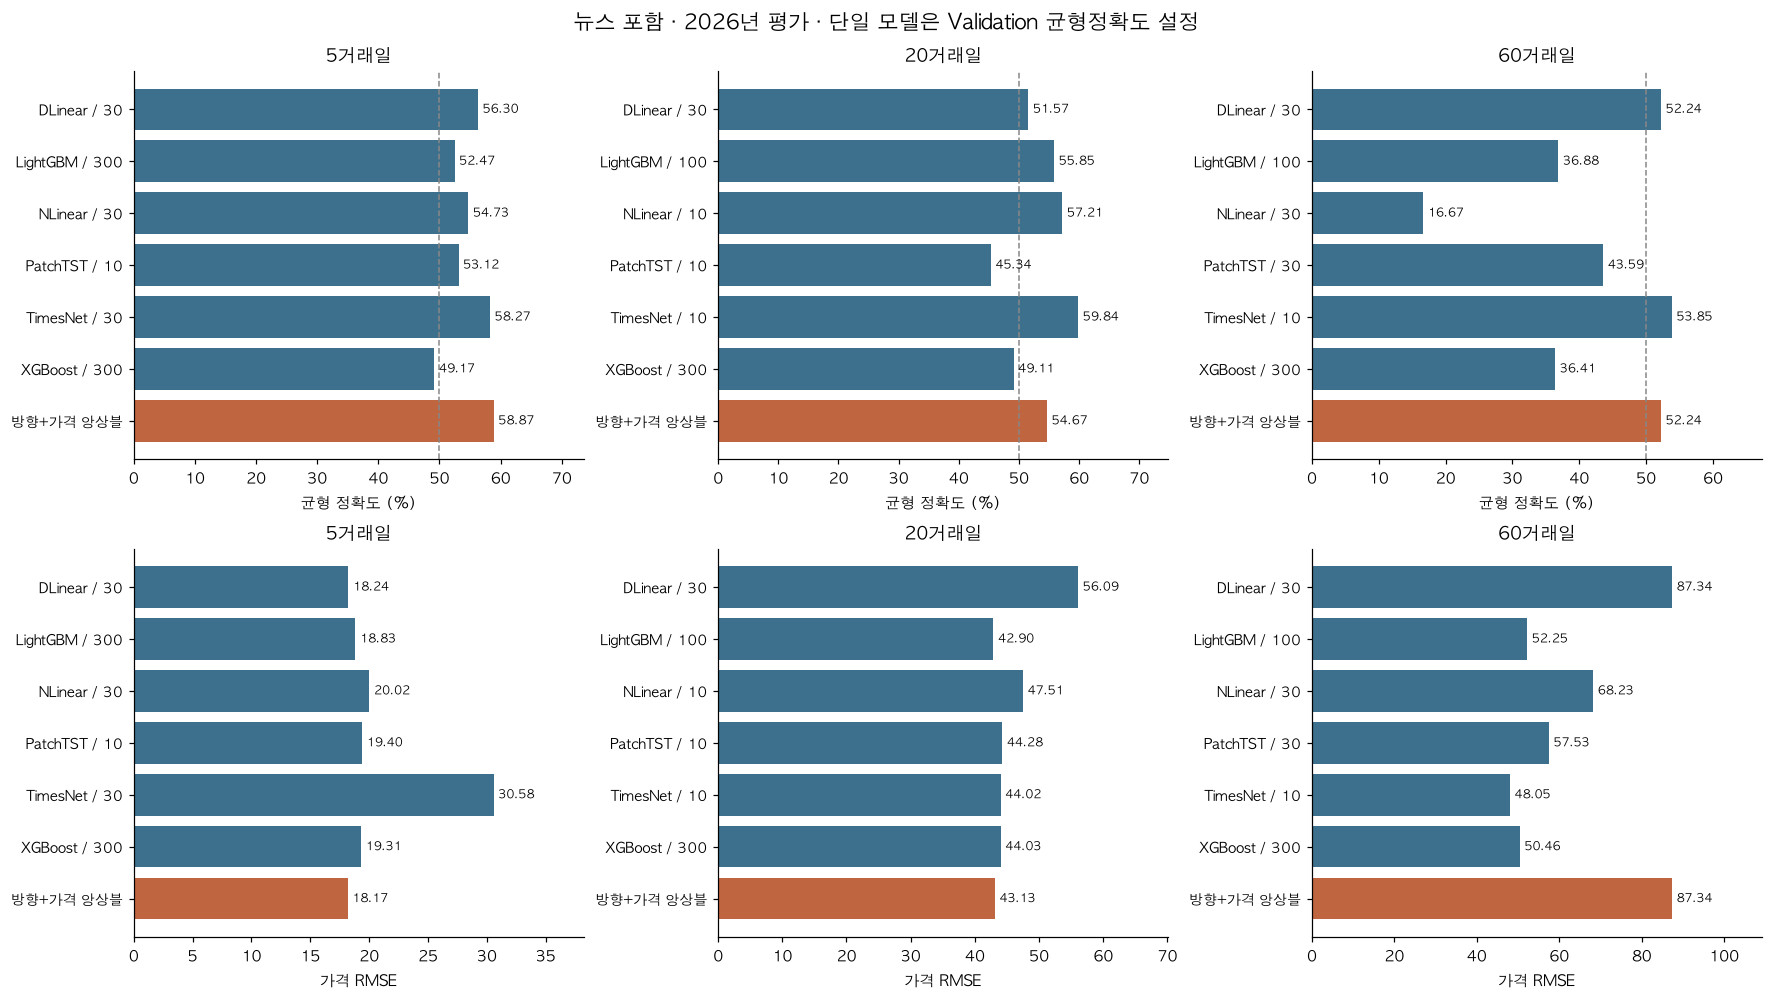

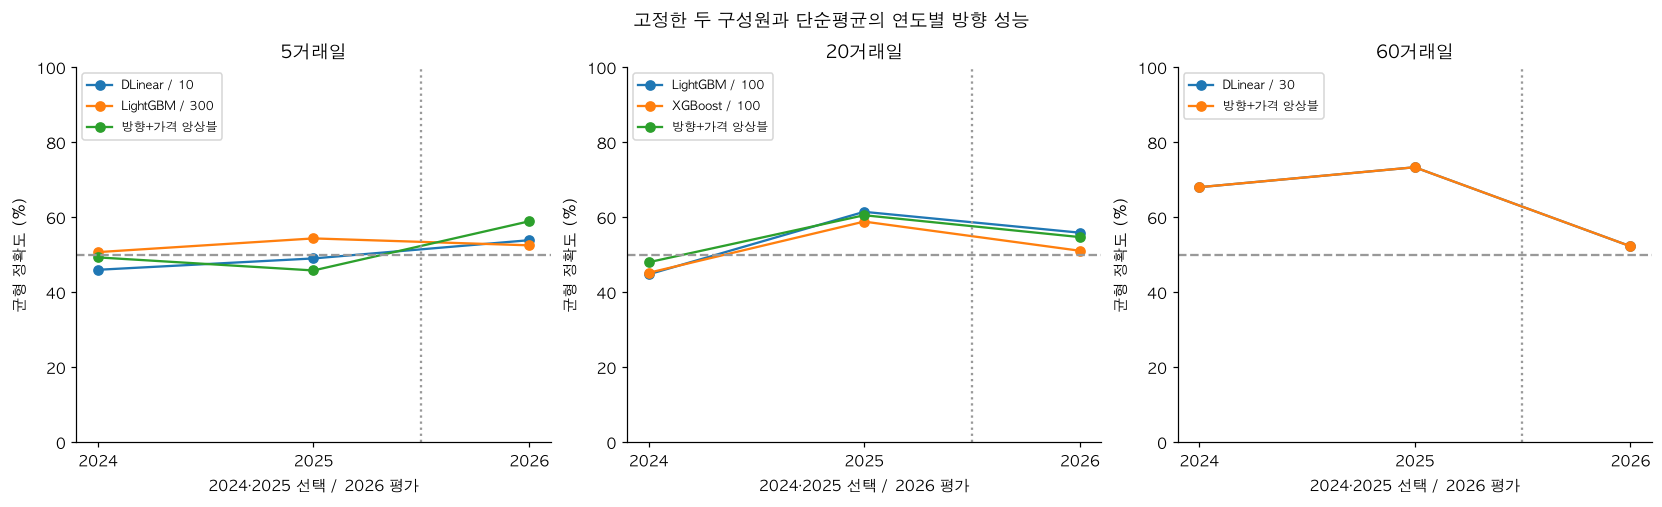

In [8]:
fig,axes=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
for col,h in enumerate(HORIZONS):
    chosen=per_model.loc[per_model["지평"].eq(h)&per_model["선택 기준"].eq("균형정확도"),"후보"].tolist()
    table=evaluation.loc[evaluation["지평"].eq(h)&evaluation["후보"].isin(chosen)].copy()
    ensemble=comparison.loc[comparison["기간"].eq("2026 평가")&comparison["지평"].eq(h)&comparison["역할"].eq("가격 단순평균")].iloc[0]
    table=pd.concat([table,pd.DataFrame([{**ensemble.to_dict(),"후보":"방향+가격 앙상블"}])],ignore_index=True)
    labels=table["후보"].str.replace("@"," / ",regex=False)
    for ax,metric in zip(axes[:,col],["균형 정확도 (%)","가격 RMSE"]):
        bars=ax.barh(range(len(table)),table[metric],color=["#BF653F" if n=="방향+가격 앙상블" else "#3D708C" for n in table["후보"]])
        ax.set(yticks=range(len(table)),yticklabels=labels,xlabel=metric,title=f"{h}거래일")
        ax.invert_yaxis();ax.bar_label(bars,fmt="%.2f",padding=3,fontsize=8)
        ax.tick_params(axis="y",labelsize=9)
        ax.set_xlim(0,max(table[metric].max()*1.25,65 if metric.startswith("균형") else 0))
        if metric.startswith("균형"):ax.axvline(50,color="#888888",linestyle="--",linewidth=1)
fig.suptitle("뉴스 포함 · 2026년 평가 · 단일 모델은 Validation 균형정확도 설정",fontsize=14)
plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,4.5),constrained_layout=True)
for ax,h in zip(axes,HORIZONS):
    for candidate,part in yearly.loc[yearly["지평"].eq(h)].groupby("후보"):
        part=part.sort_values("연도")
        ax.plot(part["연도"],part["균형 정확도 (%)"],marker="o",label=candidate.replace("@"," / "))
    ax.axvline(2025.5,color="#999999",linestyle=":")
    ax.axhline(50,color="#999999",linestyle="--")
    ax.set(title=f"{h}거래일",xticks=[2024,2025,2026],xlabel="2024·2025 선택 / 2026 평가",ylabel="균형 정확도 (%)",ylim=(0,100))
    ax.legend(fontsize=8)
fig.suptitle("고정한 두 구성원과 단순평균의 연도별 방향 성능")
plt.show()


## 8. 실행 검사와 산출물

학습 정답이 fold 마감을 넘지 않는지, 모든 예측이 학습 마감 이후인지, 모든 후보가 동일 날짜를 쓰는지, 실제 뉴스 조건에 따라 복귀하는지 검사한다. Naive 제외·중복 사례·가격 평균·모델 저장/로드도 확인한다. 원자료와 기존 노트북은 유지하고 새 run 아래 산출물을 저장한다.


In [9]:
assert protocol_path.read_text()==protocol_text
for raw in (validation_predictions,evaluation_predictions):
    assert raw.use_news.all() and raw.feature_count.eq(28).all()
    assert raw.origin_date.gt(raw.train_cutoff).all()
    assert raw.origin_date.lt(raw.target_date).all()
    assert not raw.duplicated(["horizon","candidate","origin_date"]).any()
    assert not raw.model.str.contains("Persistence|Naive").any()
for path in (OUTPUT/"models").rglob("*.npz"):
    state=np.load(path)
    assert max(state["train_target_dates"])<=str(state["train_cutoff"])
    assert min(state["train_origin_dates"])>="2022-01-01"
assert len(validation)==len(HORIZONS)*len(MODELS)*2
assert len(per_model)==len(HORIZONS)*len(MODELS)*2
artifacts={"validation_predictions.parquet":validation_predictions,"evaluation_predictions.parquet":evaluation_predictions,
    "all_forecasts.parquet":all_forecasts,"validation.csv":validation,"per_model_selection.csv":per_model,
    "leaders.csv":leaders,"evaluation.csv":evaluation,"comparison.csv":comparison,"yearly.csv":yearly,
    "intervals.csv":intervals,"fold_audit.csv":pd.DataFrame(fold_audit),"news_audit.csv":news_audit.reset_index()}
for filename,frame in artifacts.items():
    path=OUTPUT/filename
    if path.suffix==".parquet":
        if path.exists():pd.testing.assert_frame_equal(pd.read_parquet(path),frame,check_exact=True)
        else:frame.to_parquet(path,index=False)
    else:
        text=frame.to_csv(index=False)
        if path.exists():assert path.read_text()==text,f"재실행 충돌: {filename}"
        else:path.write_text(text)
print("검사 통과 및 저장:",OUTPUT.relative_to(ROOT))


검사 통과 및 저장: data/processed/news_feature_ensemble/expanding_7f2729fd5ce23b69


## 해석과 다음 단계

**표본을 늘려 재학습했지만, 모든 지평에서 안정적인 방향 개선이나 앙상블 우위를 확인한 것은 아니다.** 이전03_6의2022년 학습→2023년 Validation 대신2022~2023/2024년으로 학습을 확대했고, 최종 모델은2022~2025년 자료를 사용했다. 모델 종류·설정 선택 기간도 바뀌었으므로 변화 전부를 표본 수의 인과 효과로 해석할 수 없다. 뉴스 없는 비교군이 별도로 없으므로 이번 결과로 뉴스 추가 효과를 추정하지 않는다.

- **5일:** 평균의2026 균형정확도58.87%는 LightGBM52.47%보다 높다. 고정 예측의 짝지은 블록10 구간에서 차이는+0.18~+14.54pp지만, DLinear 대비 구간은0을 포함한다. Validation에서는 평균이 방향1위 단일보다 낮았으므로2026 성적만으로 평균을 최종 채택하지 않는다. 평균의 상승 precision은71/151=47.02%로 실제 상승 비율41.90%를 넘지만, 매수 신호 중 절반 이상은 실제 상승이 아니었다.
- **20일:** 구성원으로 고정한 LightGBM100은2026 균형55.85%·방향55.49%·RMSE42.9016, 평균은54.67%·54.27%·43.1259다. 점 추정치는 LightGBM에 유리하지만 비교 구간은0을 포함한다. LightGBM의 연도별 균형정확도44.72%/61.41%/55.85%는2024년의 약점을 보여 준다. 전체 평가에서 TimesNet10이 더 높았다는 사후 사실과 Validation 선택을 구분한다.
- **60일:** 같은 DLinear30이 두 기준에서 선택돼 평균의 추가 효과는 없다. Validation 전체 균형65.90%와 달리2026년은52.24%다. 특히2024 Validation은192건 중 하락이5건뿐이므로 그해 하락 recall과 균형정확도는 소수 사례에 민감하다. 연도별 균형정확도의 단순평균과 두 해 예측을 합산한 지표도 다르다. 2026년에는124건 중117건에 상승 신호를 냈고 실제 상승 적중은58건(49.57%)으로, 방향 우위를 강하게 주장하기 어렵다.

지금의 모델 선택은2024·2025년 예측만 사용하며2026년 성적을 보고 새로운 구성·비율·설정을 찾지 않는다. 상승 누락을 허용하고 방향을 우선하는 목적에서 다음 검증은 더 많은 시간순 구간의 안정성, 확률 기반 판단 보류, 실제 이용 가능 시점의 뉴스와 실현 구매 비용이다. 현재 결과는 소급 뉴스·이전에 본 평가 기간·한 seed·제한된 설정이라는 한계를 갖는다. 서빙 모델·DB·배포는 변경하지 않았다.
